# 1.0 Point Cloud Creation

This notebook builds one point cloud per cell/nucleus using only DDR-marker-based intensity features from the MultiFoci table.

Each point represents one focus object, and each point feature is an intensity feature matching the selected DDR markers.

In [1]:
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

ROOT = Path('/nfs/roberts/pi/pi_sk2433/shared/JohnLock_2026_DDR')
CELLS_FILE = ROOT / 'cells_classified-003.parquet'
MULTI_FILE = ROOT / 'MultiFoci_combined.parquet'

OUT_DIR = Path('DDR/pointcloud_outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_LABEL = 'Cell_State_Thr'

DDR_MARKERS = [
    'pH2AX', 'RAD51', 'Ku7080', 'pATM', 'ATM', '53BP1', 'RPA70',
    'PARP1', 'EXO1', 'BRCA1', 'BRCA2', 'MRE11A', 'CHEK1', 'CHEK2',
    'cGAS', 'STING'
]

print('Cells file exists:', CELLS_FILE.exists())
print('Multi file exists:', MULTI_FILE.exists())
print('Output directory:', OUT_DIR.resolve())

Cells file exists: True
Multi file exists: True
Output directory: /nfs/roberts/project/pi_sk2433/sv496/HiPoNet/DDR/DDR/pointcloud_outputs


## 1) Select DDR marker intensity features

We scan the MultiFoci schema for columns that look like:

- `Intensity_MeanIntensity_..._<marker>`

and keep only the ones matching the DDR marker list supplied above.

In [2]:
parquet_file = pq.ParquetFile(MULTI_FILE)
all_multi_cols = parquet_file.schema.names

point_feature_cols = [
    c for c in all_multi_cols
    if c.startswith('Intensity_MeanIntensity_')
    and any(f'_{marker}' in c for marker in DDR_MARKERS)
]

# Remove duplicates while preserving order
seen = set()
point_feature_cols = [c for c in point_feature_cols if not (c in seen or seen.add(c))]

if not point_feature_cols:
    raise ValueError('No DDR marker intensity features were found in the MultiFoci schema.')

print('Found marker feature columns:', len(point_feature_cols))
print(point_feature_cols)

Found marker feature columns: 16
['Intensity_MeanIntensity_Cycle01_Ku7080', 'Intensity_MeanIntensity_Cycle01_RAD51', 'Intensity_MeanIntensity_Cycle01_pH2AX', 'Intensity_MeanIntensity_Cycle02_pATM(1981)', 'Intensity_MeanIntensity_Cycle03_ATM', 'Intensity_MeanIntensity_Cycle03_EXO1', 'Intensity_MeanIntensity_Cycle04_BRCA1', 'Intensity_MeanIntensity_Cycle05_BRCA2', 'Intensity_MeanIntensity_Cycle05_cGAS', 'Intensity_MeanIntensity_Cycle06_MRE11A', 'Intensity_MeanIntensity_Cycle07_CHEK1', 'Intensity_MeanIntensity_Cycle07_CHEK2', 'Intensity_MeanIntensity_Cycle08_53BP1', 'Intensity_MeanIntensity_Cycle10_STING', 'Intensity_MeanIntensity_Cycle13_RPA70', 'Intensity_MeanIntensity_Cycle15_PARP1']


## 2) Load cell labels and join them to foci rows

We keep only cells with a non-missing target label and then join those cells to their corresponding foci rows.

In [3]:
required_cells = ['Nuclei_ImageNumber', 'Nuclei_ObjectNumber', TARGET_LABEL]
missing_cells = [c for c in required_cells if c not in pq.ParquetFile(CELLS_FILE).schema.names]
if missing_cells:
    raise ValueError(f'Missing required cell columns: {missing_cells}')

cells = pd.read_parquet(
    CELLS_FILE,
    columns=required_cells,
).rename(columns={'Nuclei_ImageNumber': 'ImageNumber', 'Nuclei_ObjectNumber': 'ObjectNumber'})

cells = cells.dropna(subset=[TARGET_LABEL]).copy()

multi = pd.read_parquet(
    MULTI_FILE,
    columns=['ImageNumber', 'ObjectNumber'] + point_feature_cols,
)

joined = cells.merge(multi, on=['ImageNumber', 'ObjectNumber'], how='inner')
joined = joined.dropna(subset=point_feature_cols).copy()

print('Cells after filtering:', cells.shape[0])
print('Joined rows:', joined.shape[0])
print('Unique labeled cells:', joined[['ImageNumber', 'ObjectNumber']].drop_duplicates().shape[0])
print('Label distribution:')
print(joined[TARGET_LABEL].value_counts(dropna=False).to_string())

Cells after filtering: 27039
Joined rows: 45337
Unique labeled cells: 21603
Label distribution:
Cell_State_Thr
Intermediate            38249
Resisting Cell Death     3135
Stressed                 1504
Proliferative            1486
Late Apoptotic            555
Early Apoptotic           408


## 3) Build per-cell point clouds

For each cell, we collect all foci rows belonging to that cell as a variable-length point cloud.
No minimum or maximum point-count limit is applied here; we simply record how many points ended up in each cloud.

In [ ]:
clouds, labels, keys, cloud_sizes = [], [], [], []

# Sanity check the target labels before building point clouds
label_values = np.asarray(joined[TARGET_LABEL].tolist())
print('Label dtype:', label_values.dtype)
print('Null label count:', int(pd.isna(label_values).sum()))
print('Unique labels:', np.unique(label_values))
print('Label counts:')
print(pd.Series(label_values).value_counts(dropna=False).to_string())

for (img_id, obj_id), g in joined.groupby(['ImageNumber', 'ObjectNumber'], sort=False):
    pts = g[point_feature_cols].to_numpy(dtype=np.float32)

    clouds.append(pts)
    labels.append(g[TARGET_LABEL].iloc[0])
    keys.append((int(img_id), int(obj_id)))
    cloud_sizes.append(int(pts.shape[0]))

print('Number of point clouds created:', len(clouds))
print('First cloud shape:', clouds[0].shape)
print('First label:', labels[0])
print('First key:', keys[0])
print('Point-cloud sizes (first 10):', cloud_sizes[:10])
print('Cloud size summary:')
print(pd.Series(cloud_sizes).describe().to_string())

# Sanity check: verify that the raw point-cloud features are finite
first_cloud = clouds[0]
print('First cloud contains NaN:', np.isnan(first_cloud).any())
print('First cloud contains Inf:', np.isinf(first_cloud).any())

if len(clouds) > 1:
    flat_values = np.concatenate([c.reshape(-1) for c in clouds[:1000]], axis=0)
    print('NaN count across first 1000 clouds:', int(np.isnan(flat_values).sum()))
    print('Inf count across first 1000 clouds:', int(np.isinf(flat_values).sum()))
else:
    print('Not enough clouds to inspect the aggregate NaN/Inf counts.')

Number of point clouds created: 21603
First cloud shape: (5, 16)
First label: Intermediate
First key: (1, 1)
Point-cloud sizes (first 10): [5, 5, 5, 4, 4, 4, 4, 4, 4, 3]
Cloud size summary:
count    21603.000000
mean         2.098644
std          0.944894
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          5.000000


## 4) Save the point-cloud dataset

The output is saved as a pickle so it can be reused later in training or visualization notebooks.

In [ ]:
dataset = {
    'clouds': clouds,
    'labels': labels,
    'keys': keys,
    'cloud_sizes': cloud_sizes,
    'point_feature_cols': point_feature_cols,
    'target_label': TARGET_LABEL,
    'ddr_markers': DDR_MARKERS,
}

out_path = OUT_DIR / 'ddr_pointclouds.pkl'
with open(out_path, 'wb') as f:
    pickle.dump(dataset, f)

print('Saved point-cloud dataset to:', out_path.resolve())

Saved point-cloud dataset to: /nfs/roberts/project/pi_sk2433/sv496/HiPoNet/DDR/DDR/pointcloud_outputs/ddr_pointclouds.pkl


In [7]:
# Reload the saved pickle and verify that the data is still finite
with open(out_path, 'rb') as f:
    reloaded = pickle.load(f)

reloaded_clouds = reloaded['clouds']
print('Reloaded dataset clouds:', len(reloaded_clouds))
print('Reloaded first cloud shape:', reloaded_clouds[0].shape)
print('Reloaded first cloud contains NaN:', np.isnan(reloaded_clouds[0]).any())
print('Reloaded first cloud contains Inf:', np.isinf(reloaded_clouds[0]).any())

sample_count = len(reloaded_clouds)
flat_values = np.concatenate([c.reshape(-1) for c in reloaded_clouds[:sample_count]], axis=0)
print('Reloaded NaN count across first {} clouds:'.format(sample_count), int(np.isnan(flat_values).sum()))
print('Reloaded Inf count across first {} clouds:'.format(sample_count), int(np.isinf(flat_values).sum()))

Reloaded dataset clouds: 21603
Reloaded first cloud shape: (5, 16)
Reloaded first cloud contains NaN: False
Reloaded first cloud contains Inf: False
Reloaded NaN count across first 21603 clouds: 0
Reloaded Inf count across first 21603 clouds: 0


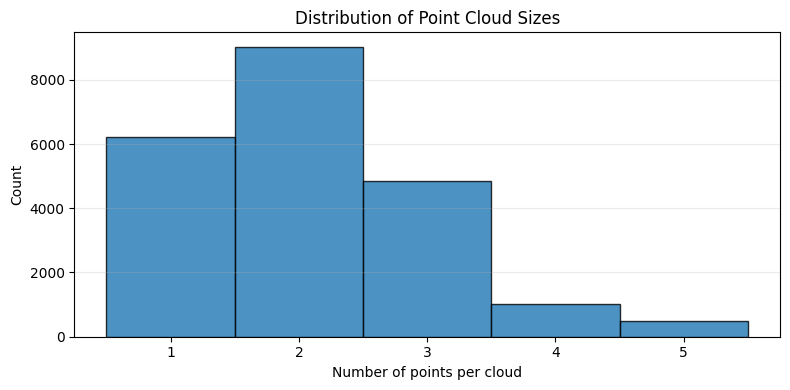

count    21603.000000
mean         2.098644
std          0.944894
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          5.000000
dtype: float64


In [8]:
import matplotlib.pyplot as plt

sizes = np.asarray(dataset.get('cloud_sizes', [c.shape[0] for c in clouds]))

plt.figure(figsize=(8, 4))
bins = np.arange(sizes.min(), sizes.max() + 2) - 0.5  # integer-centered bins
plt.hist(sizes, bins=bins, edgecolor='black', alpha=0.8)
plt.title('Distribution of Point Cloud Sizes')
plt.xlabel('Number of points per cloud')
plt.ylabel('Count')
plt.xticks(np.arange(sizes.min(), sizes.max() + 1))
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

print(pd.Series(sizes).describe())